In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from matplotlib_venn import venn2, venn3
from scipy.ndimage.filters import gaussian_filter

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_16122/1649472044.py:30: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_aperture_mass.txt",'rb') as f: 
    tab=pickle.load(f)
mask=(tab['proj']=='xy')
tab1=tab[mask]

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_satellite_mass.txt",'rb') as f: 
    tab_rich0=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_cylinder_richness_satellite_mass.txt",'rb') as f: 
    tab_rich=pickle.load(f)

In [6]:
tab2=hstack([tab[mask],tab_rich0[tab_rich0.colnames[2:]],tab_rich[tab_rich.colnames[2:]]])

In [7]:
df = pd.read_csv(data_dir+'tng_snap.csv')
age_tab=np.asarray(df['age'])
z_tab=np.asarray(df['redshift'])

In [8]:
cmap1=palettable.lightbartlein.diverging.BlueDarkRed18_10.mpl_colormap

In [9]:
with open(data_dir+"galaxies_tng300_072_hmc_13_stellar_mass_history_sublink_processed.txt",'rb') as f: 
    tab_smh=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_hmc_13_stellar_mass_history_sublink_GrNr.txt",'rb') as f: 
    tab_grnr=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_subh_hmc.txt",'rb') as f: 
    tab_subh=pickle.load(f)
with open(data_dir+"galaxies_tng300_072_mah_hmc.txt",'rb') as f: 
    tab_mah=pickle.load(f)

In [10]:
mpeak_hist=[[],]
gal_num_exl=[]
for gal_num in range(3388):
    if (len(tab_mah[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_mah[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['mass_halo'][gal_num]],tab_mah[gal_num][1]*1e10/0.6774))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        gal_num_exl.append(gal_num)
        xdata0=[None]
        ydata0=[None]
    mpeak_hist.append([xdata0,ydata0])
del mpeak_hist[0]

In [11]:
mask_exl=(tab2['aper_100_gal']>0)
for i in gal_num_exl:
    mask_exl=mask_exl&(tab2['gal_num']!=i)

In [12]:
mask1=(tab2['c_200c']<15)&mask_exl

In [13]:
age_list=age_tab[32:73]

In [14]:
smh_list=[[],]
for gal_num in range(3388):
    mask=(tab_smh[gal_num]['snapshot']>20)
    xdata=age_tab[tab_smh[gal_num][mask]['snapshot']]
    ydata=tab_smh[gal_num][mask]['mass_stellar']
    if np.min(xdata)<2:
        f=interp1d(xdata,ydata,kind='cubic')
        ydata0=f(age_list)
    else:
        ydata0=[None]
    smh_list.append(ydata0)
del smh_list[0]

In [15]:
subh_hist=[[],]
for gal_num in range(3388):
    if (len(tab_subh[gal_num][0])>0):
        xdata=np.flip(np.append([72],tab_subh[gal_num][0].astype(np.int64)))
        ydata=np.flip(np.append([tab2['richness_cut_r200_8.5'][gal_num]],tab_subh[gal_num][1]))
        xdata0=[xdata[0],]
        ydata0=[ydata[0],]
        for i in range(1,len(xdata)):
            xdata0.append(xdata[i])
            if ydata[i]>ydata0[i-1]:
                ydata0.append(ydata[i])
            else:
                ydata0.append(ydata0[i-1])
    else:
        xdata0=[None]
        ydata0=[None]
    subh_hist.append([xdata0,ydata0])
del subh_hist[0]

In [16]:
def stack_smh(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            if smh_list[gal_num][0]!=None:
                prof_curve.append(smh_list[gal_num])
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
    return np.asarray(median)
def stack_mah(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            x=age_tab[mpeak_hist[gal_num][0]]
            y=np.asarray(mpeak_hist[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00]/y[mask00][-1],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
    return np.asarray(median)
def stack_subh(gal_num_list):
    prof_curve=[]
    median=[]
    upper=[]
    lower=[]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for gal_num in gal_num_list:
            gal_num=int(gal_num)
            x=age_tab[subh_hist[gal_num][0]]
            y=np.asarray(subh_hist[gal_num][1])
            mask00=(x>1)
            if np.min(x[mask00])<3:
                f=interp1d(x[mask00],y[mask00],kind='cubic')
                prof_curve.append(f(age_list))
        for i in range(len(age_list)):
            median.append(np.median(np.asarray(prof_curve).T[i]))
            upper.append(np.percentile(np.asarray(prof_curve).T[i],84))
            lower.append(np.percentile(np.asarray(prof_curve).T[i],16))
    return np.asarray(median)

In [17]:
def bootstrap_smh(gal_num_list,age_list,times=3000):
    smh_list_0=[]
    for ii in range(times):
        gal_rand=resample_list(gal_num_list)
        smh=stack_smh_mean(gal_rand)
        smh_list_0.append(smh)
    upper=[]
    lower=[]
    for j in range(len(age_list)):
        upper.append(np.percentile(np.asarray(smh_list_0).T[j],84))
        lower.append(np.percentile(np.asarray(smh_list_0).T[j],16))
    return np.asarray(upper),np.asarray(lower)


In [18]:
def topNselect(data,name,number):
    data_meta=data.group_by(name)
    data0=data_meta[-number::]
    return data0
def topNoutselect(data,name1,name2,number):
    data_meta=data.group_by(np.log10(data[name1]-data[name2]))
    data0=data_meta[-number::]
    return data0
def linear1d(x,a,b):
    return a*x+b
def mpeakfind(tab,bin_num=30):
    numb,bins=np.histogram(tab,bins=bin_num)
    max_value=max(numb)
    max_index=list(numb).index(max_value)
    mpeak=bins[max_index]
    return mpeak
def resample_list(tab):
    length=len(tab)
    list0=np.random.randint(length,size=length)
    return tab[list0]

In [19]:
mask1=(tab2['c_200c']<15)&mask_exl
name='richness_cut_r200_10'
label=r'$\log\lambda_{\log M_\star>10,R_{200}}$'
top_numb=600
ydata=np.log10(tab2[mask1]['aper_100_gal']-tab2[mask1]['aper_50_gal'])
topNout=topNoutselect(tab2[mask1],'aper_100_gal','aper_50_gal',top_numb)
mask_l=(ydata>=np.min(np.log10(topNout['aper_100_gal']-topNout['aper_50_gal'])))
xdata=np.log10(tab2[mask1][name])
mask_h1=(xdata>np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
mask_h2=(xdata==np.min(np.log10(topNselect(tab2[mask1],name,top_numb)[name])))
index_list=np.where(mask_h2==True)[0]
true_num=top_numb-len(xdata[mask_h1])
array=np.zeros(len(index_list))
array[:true_num]=1
np.random.shuffle(array)
for j in range(len(index_list)):
    index=index_list[j]
    mask_h2[index]=mask_h2[index]&bool(array[j])
mask_h=mask_h1|mask_h2
mask_up=mask_l&(~mask_h)
mask_down=mask_h&(~mask_l)
mask_cro=mask_h&mask_l
    
up_data=tab2[mask1][mask_up]
down_data=tab2[mask1][mask_down]
up_data_gal_num=up_data['gal_num']
down_data_gal_num=down_data['gal_num']


median_smh_upp=stack_smh(up_data_gal_num)
median_smh_down=stack_smh(down_data_gal_num)
median_mah_upp=stack_mah(up_data_gal_num)
median_mah_down=stack_mah(down_data_gal_num)
median_subh_upp=stack_subh(up_data_gal_num)
median_subh_down=stack_subh(down_data_gal_num)




/var/folders/x0/h_lnpc2s7tj88s2gg8lg03l80000gn/T/ipykernel_16122/3135015173.py:8: RuntimeWarning: divide by zero encountered in log10
  xdata=np.log10(tab2[mask1][name])


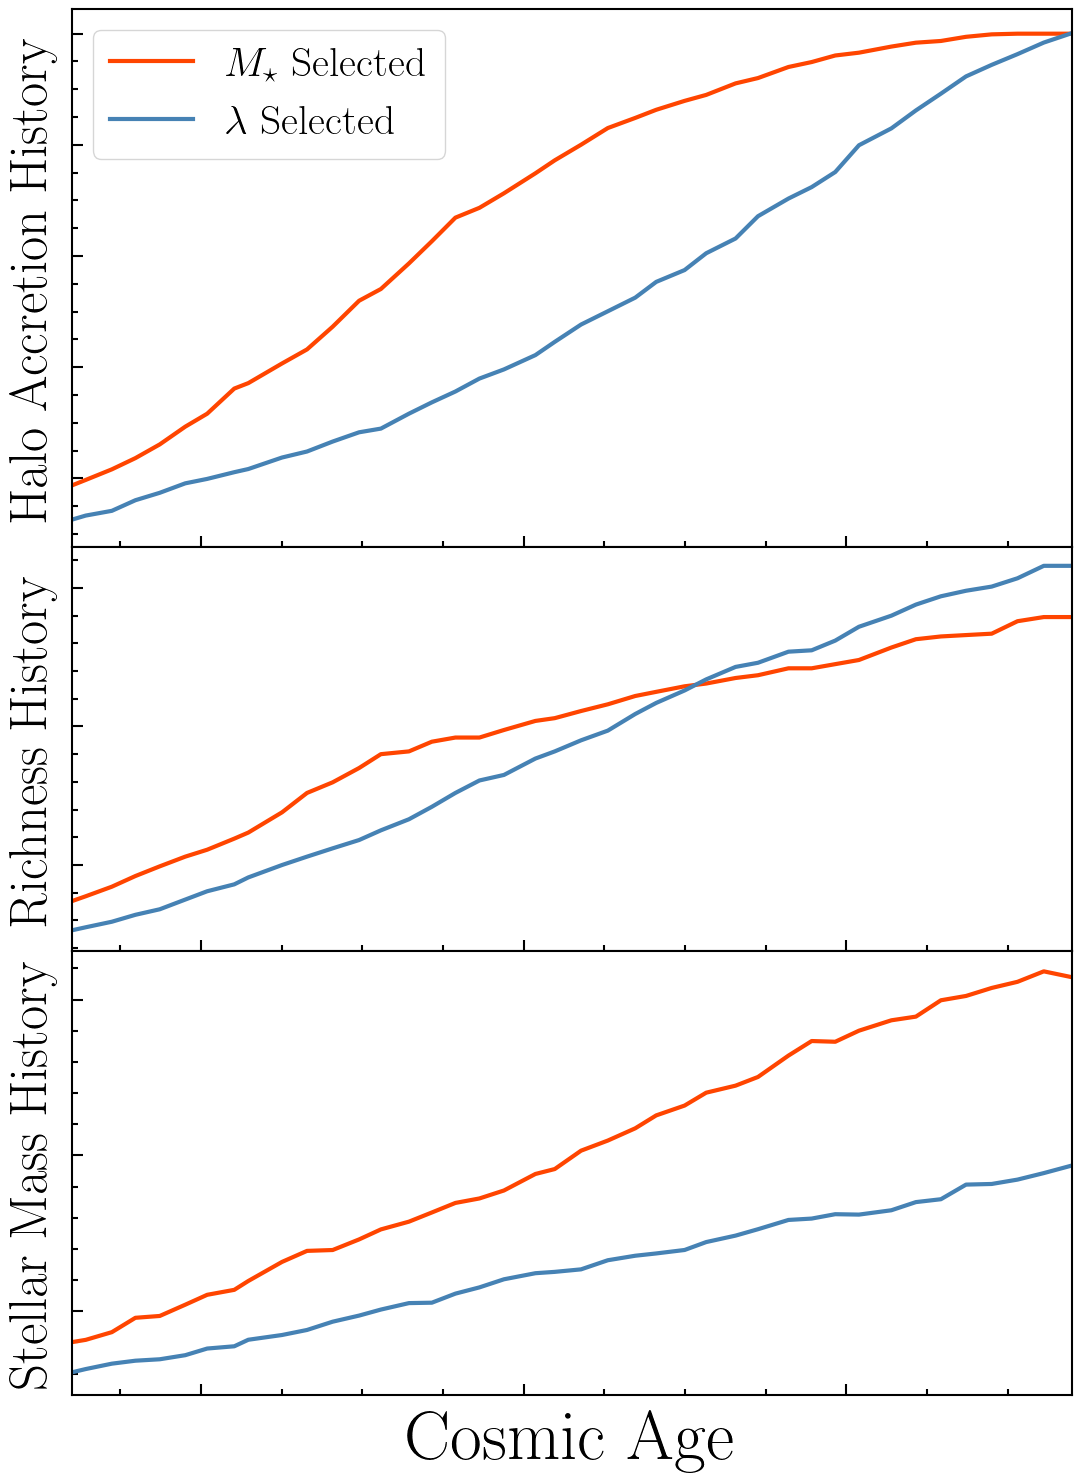

In [27]:
from matplotlib.gridspec import GridSpec
fig=plt.figure(figsize=(10,18))
gs_right = GridSpec(3, 1, left=0, right=1, hspace=0, height_ratios=(0.4,0.3,0.33))  # No vertical space


ax22= fig.add_subplot(gs_right[0])
ax21 = fig.add_subplot(gs_right[1],sharex=ax22)
ax20 = fig.add_subplot(gs_right[2],sharex=ax22)

ax20.plot(age_list,median_smh_upp,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Selected}')
ax20.plot(age_list,median_smh_down,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Selected}')

ax21.plot(age_list,median_subh_upp,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Selected}')
ax21.plot(age_list,median_subh_down,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Selected}')
ax22.plot(age_list,median_mah_upp,color='orangered',lw=3,alpha=1,label=r'$M_\star$ {\rm Selected}')
ax22.plot(age_list,median_mah_down,color='steelblue',lw=3,alpha=1,label=r'$\lambda$ {\rm Selected}')

ax20.set_ylabel(r'\rm Stellar Mass History', fontsize=38)
ax21.set_ylabel(r'\rm Richness History', fontsize=38)
ax22.set_ylabel(r'\rm Halo Accretion History', fontsize=38)
ax20.set_xlim(3.2,9.4)
ax20.set_xlabel(r'\rm Cosmic Age', fontsize=50)


ax22.legend(fontsize=30)


for ax in (ax20,ax21,ax22):
    ax.set_xticklabels([])  # 隐藏 x 轴的刻度标签
    ax.set_yticklabels([])  # 隐藏 y 轴的刻度标签

plt.savefig(fig_dir+"Fig9.pdf",dpi=150,bbox_inches='tight')